# Smart Meter Anomaly Detection Analysis
# This notebook implements various anomaly detection methods for smart meter data

**Checks the columns**

In [1]:
import pandas as pd
import numpy as np

check_columns = pd.read_csv('data/smart_meter_grid_south_africa.csv')
check_columns = check_columns.columns
print(check_columns)

Index(['Meter ID', 'Timestamp', 'Province', 'City', 'Latitude', 'Longitude',
       'Customer Type', 'Energy Consumption (kWh)', 'Solar Generation (kWh)',
       'Voltage (kV)', 'Frequency (Hz)', 'Power Factor', 'Fraud',
       'Load Shedding'],
      dtype='object')


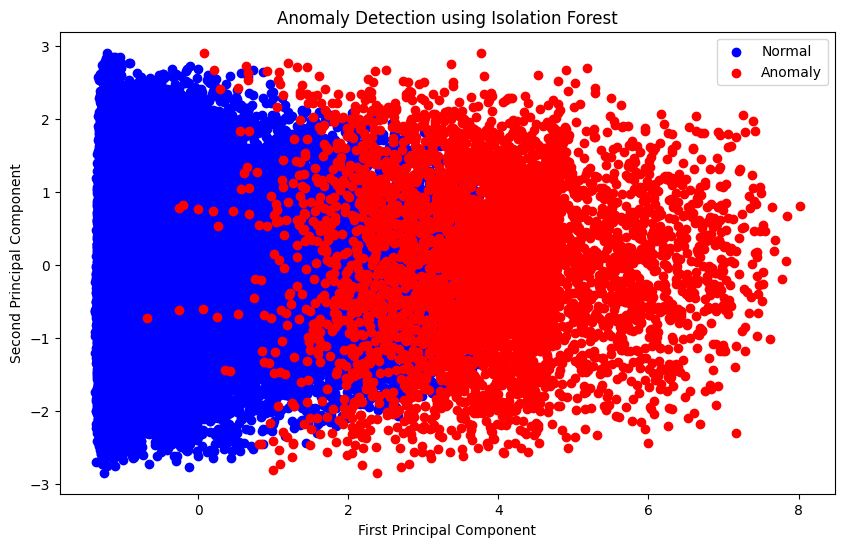

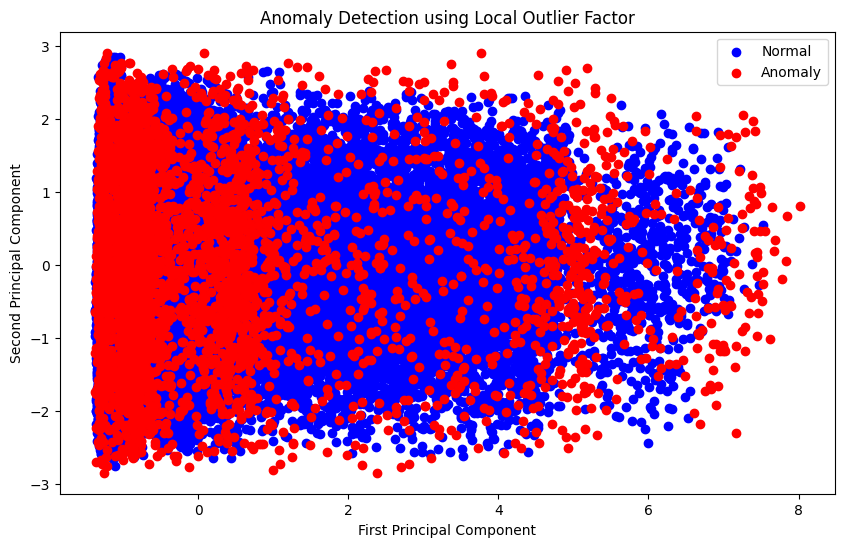

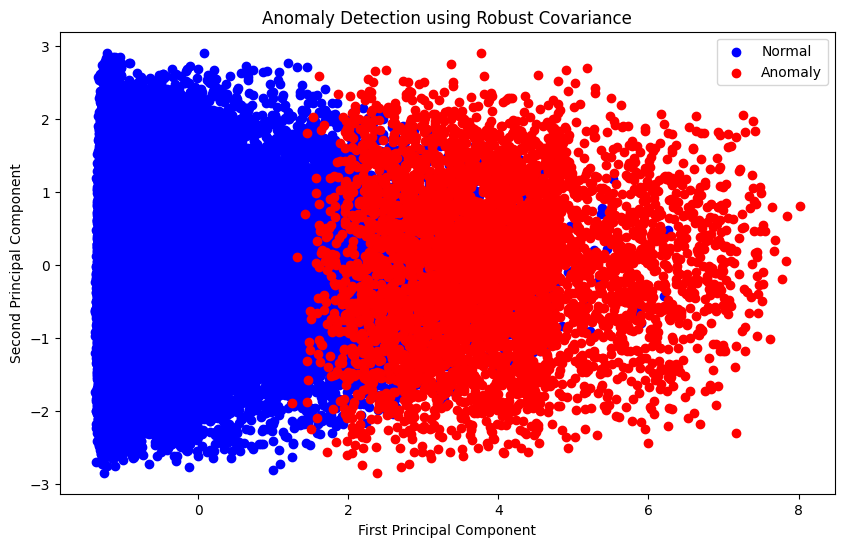

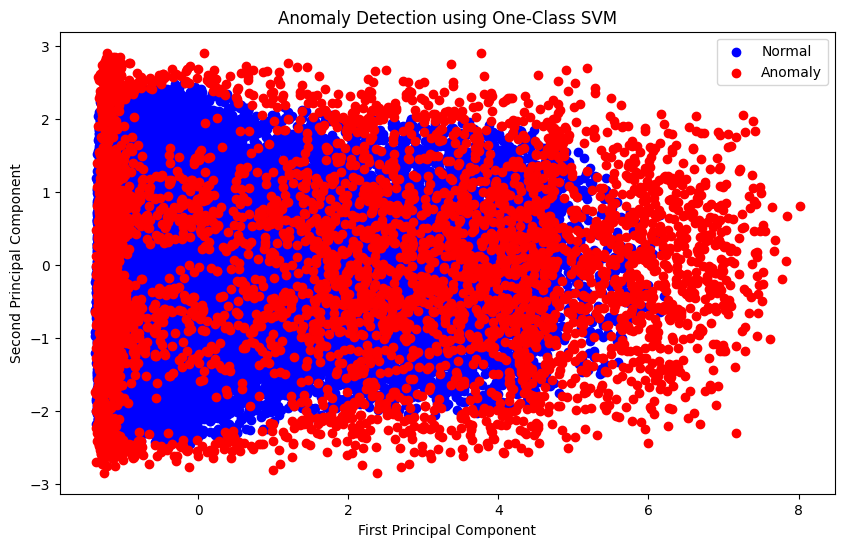

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8994
           1       0.96      0.89      0.93      1006

    accuracy                           0.99     10000
   macro avg       0.97      0.95      0.96     10000
weighted avg       0.99      0.99      0.99     10000



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load and Preprocess Data
def load_and_preprocess(file_path):
    df = pd.read_csv(file_path)
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Hour'] = df['Timestamp'].dt.hour
    df['Day'] = df['Timestamp'].dt.day
    df['Month'] = df['Timestamp'].dt.month
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    
    df['Consumption_per_voltage'] = df['Energy Consumption (kWh)'] / df['Voltage (kV)']
    df['Power_efficiency'] = df['Power Factor'] * df['Energy Consumption (kWh)']
    
    return df

# Feature Preparation
def prepare_features(df):
    features = ['Energy Consumption (kWh)', 'Voltage (kV)', 'Frequency (Hz)', 'Power Factor',
                'Consumption_per_voltage', 'Power_efficiency']
    X = df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, features

# Anomaly Detection
def detect_anomalies(X_scaled):
    methods = {
        'Isolation Forest': IsolationForest(contamination=0.1, random_state=42),
        'Local Outlier Factor': LocalOutlierFactor(contamination=0.1, n_neighbors=20),
        'Robust Covariance': EllipticEnvelope(contamination=0.1, random_state=42),
        'One-Class SVM': OneClassSVM(kernel='rbf', nu=0.1)
    }
    
    results = {}
    for name, model in methods.items():
        predictions = model.fit_predict(X_scaled)
        results[name] = predictions
    
    return results

# Visualization
def visualize_results(df, X_scaled, anomaly_labels):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    for method, labels in anomaly_labels.items():
        plt.figure(figsize=(10, 6))
        plt.scatter(X_pca[labels == 1, 0], X_pca[labels == 1, 1], c='blue', label='Normal')
        plt.scatter(X_pca[labels == -1, 0], X_pca[labels == -1, 1], c='red', label='Anomaly')
        plt.title(f'Anomaly Detection using {method}')
        plt.xlabel('First Principal Component')
        plt.ylabel('Second Principal Component')
        plt.legend()
        plt.show()

# Prediction Model
def build_prediction_model(df, anomaly_labels):
    features = ['Hour', 'Day', 'Month', 'DayOfWeek', 'Energy Consumption (kWh)', 'Voltage (kV)',
                'Frequency (Hz)', 'Power Factor']
    X = df[features]
    y = (anomaly_labels['Isolation Forest'] == -1).astype(int)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(classification_report(y_test, y_pred))
    
    return model

# Run the Analysis
file_path = "data/smart_meter_grid_south_africa.csv"
df = load_and_preprocess(file_path)
X_scaled, features = prepare_features(df)
anomaly_labels = detect_anomalies(X_scaled)
visualize_results(df, X_scaled, anomaly_labels)
prediction_model = build_prediction_model(df, anomaly_labels)


In [3]:
def plot_time_series(df):
    plt.figure(figsize=(14, 6))
    plt.plot(df['Timestamp'], df['Energy Consumption (kWh)'], label='Energy Consumption (kWh)')
    plt.title('Energy Consumption Time Series')
    plt.xlabel('Timestamp')
    plt.ylabel('Energy Consumption (kWh)')
    plt.legend()
    plt.show()

    # Daily Consumption Time Series
    daily_consumption = df.groupby(df['Timestamp'].dt.date)['Energy Consumption (kWh)'].sum()
    plt.figure(figsize=(14, 6))
    plt.plot(daily_consumption.index, daily_consumption.values, label='Daily Energy Consumption (kWh)')
    plt.title('Daily Energy Consumption Time Series')
    plt.xlabel('Date')
    plt.ylabel('Energy Consumption (kWh)')
    plt.legend()
    plt.show()

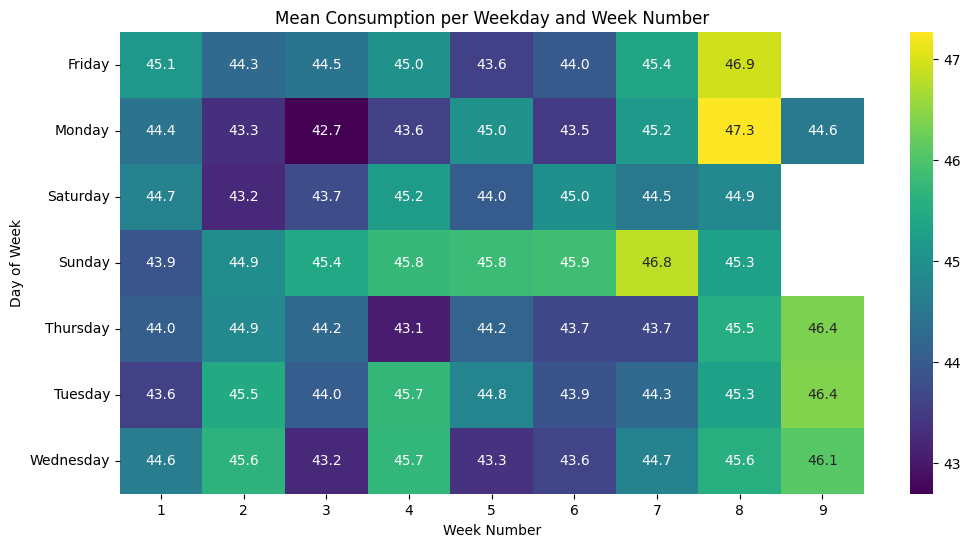

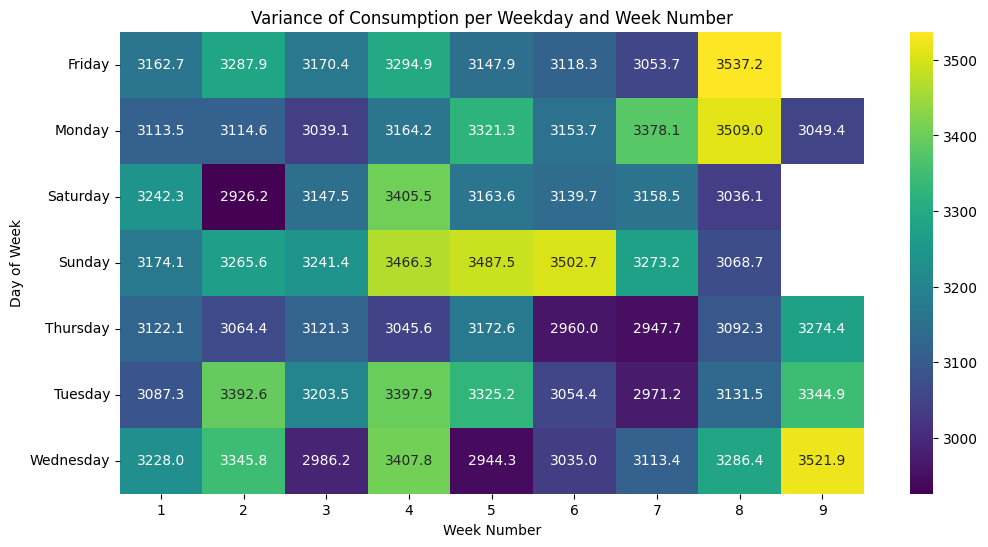

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['DayOfWeek'] = df['Timestamp'].dt.day_name()  # Extract day of the week
df['Week'] = df['Timestamp'].dt.isocalendar().week  # Extract week number

def plot_heatmaps(df):
    # Mean Consumption Heatmap
    mean_consumption = df.groupby(['DayOfWeek', 'Week'])['Energy Consumption (kWh)'].mean().unstack()
    plt.figure(figsize=(12, 6))
    sns.heatmap(mean_consumption, cmap='viridis', annot=True, fmt=".1f")
    plt.title('Mean Consumption per Weekday and Week Number')
    plt.xlabel('Week Number')
    plt.ylabel('Day of Week')
    plt.show()

    # Variance Heatmap
    variance_consumption = df.groupby(['DayOfWeek', 'Week'])['Energy Consumption (kWh)'].var().unstack()
    plt.figure(figsize=(12, 6))
    sns.heatmap(variance_consumption, cmap='viridis', annot=True, fmt=".1f")
    plt.title('Variance of Consumption per Weekday and Week Number')
    plt.xlabel('Week Number')
    plt.ylabel('Day of Week')
    plt.show()

# Call the function to plot the heatmaps
plot_heatmaps(df)

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_autocorrelation(df, anomaly_labels):
    normal_consumers = df[anomaly_labels['Isolation Forest'] == 1]
    suspicious_consumers = df[anomaly_labels['Isolation Forest'] == -1]

    # ACF for Normal Consumers
    plt.figure(figsize=(12, 6))
    plot_acf(normal_consumers['Energy Consumption (kWh)'], lags=30, title='ACF for Normal Consumers')
    plt.show()

    # ACF for Suspicious Consumers
    plt.figure(figsize=(12, 6))
    plot_acf(suspicious_consumers['Energy Consumption (kWh)'], lags=30, title='ACF for Suspicious Consumers')
    plt.show()

    # PACF for Normal Consumers
    plt.figure(figsize=(12, 6))
    plot_pacf(normal_consumers['Energy Consumption (kWh)'], lags=30, title='PACF for Normal Consumers')
    plt.show()

    # PACF for Suspicious Consumers
    plt.figure(figsize=(12, 6))
    plot_pacf(suspicious_consumers['Energy Consumption (kWh)'], lags=30, title='PACF for Suspicious Consumers')
    plt.show()

In [6]:
def simulate_and_analyze(df, anomaly_labels):
    # Add anomaly labels to the dataframe
    df['Anomaly'] = anomaly_labels['Isolation Forest']

    # Group by anomaly flag and analyze
    normal_consumers = df[df['Anomaly'] == 1]
    suspicious_consumers = df[df['Anomaly'] == -1]

    print("Normal Consumers Summary:")
    print(normal_consumers.describe())

    print("\nSuspicious Consumers Summary:")
    print(suspicious_consumers.describe())

    # Plot distribution of consumption for both groups
    plt.figure(figsize=(12, 6))
    sns.histplot(normal_consumers['Energy Consumption (kWh)'], color='blue', label='Normal', kde=True)
    sns.histplot(suspicious_consumers['Energy Consumption (kWh)'], color='red', label='Suspicious', kde=True)
    plt.title('Energy Consumption Distribution: Normal vs Suspicious Consumers')
    plt.xlabel('Energy Consumption (kWh)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

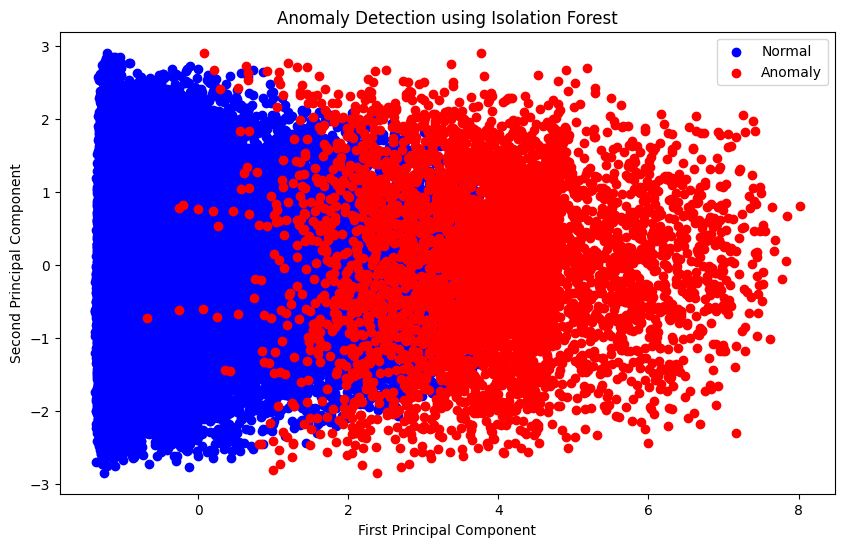

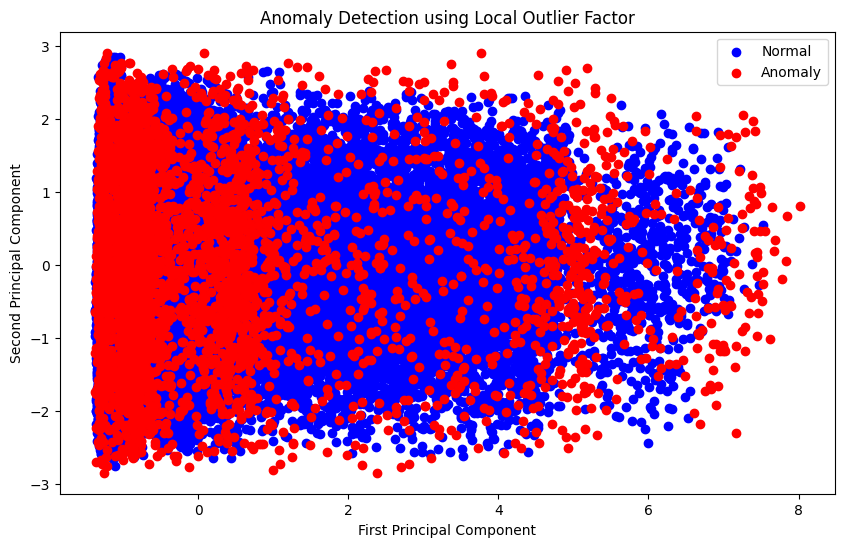

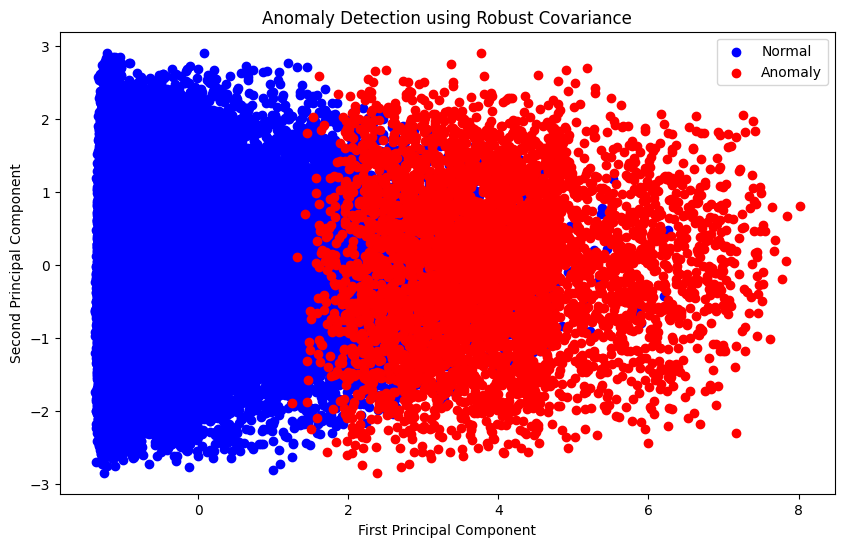

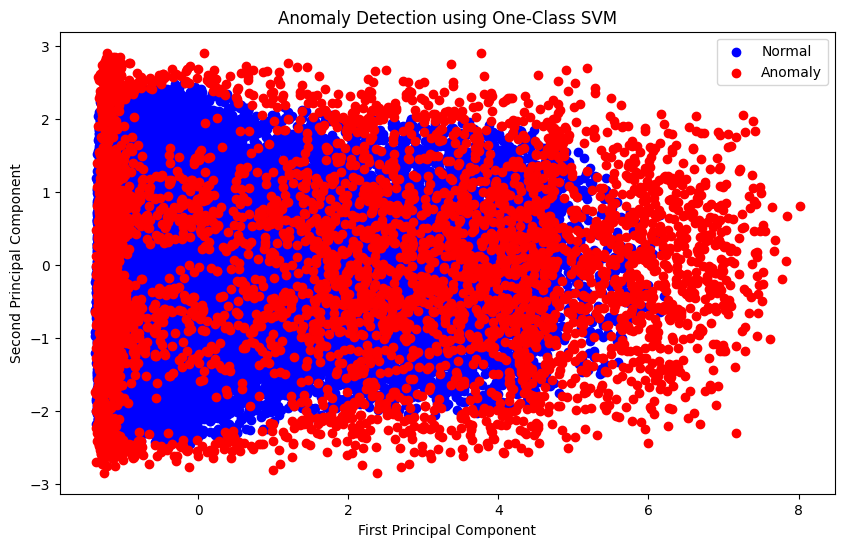

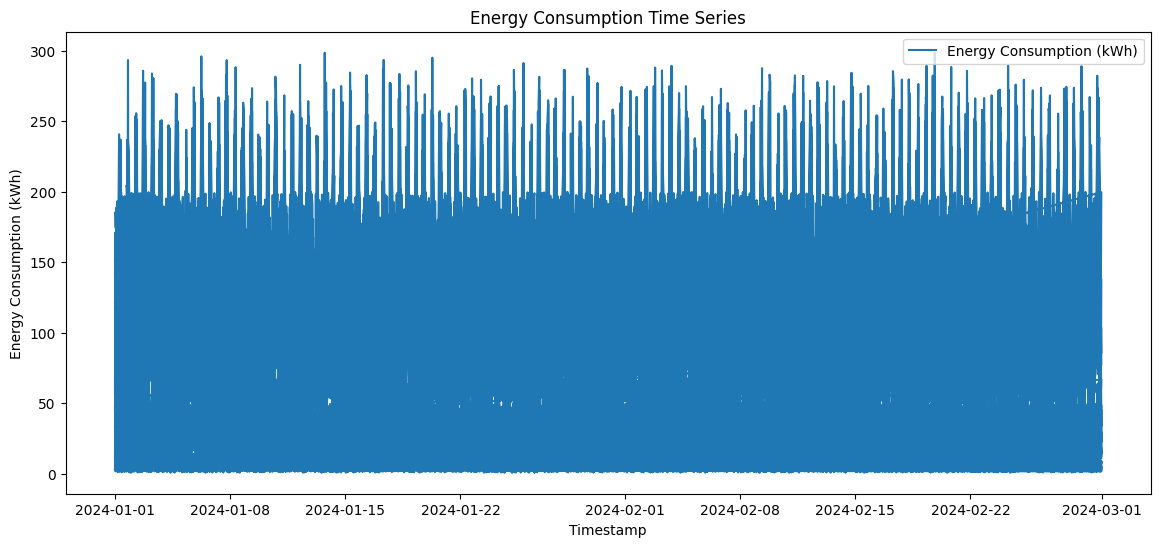

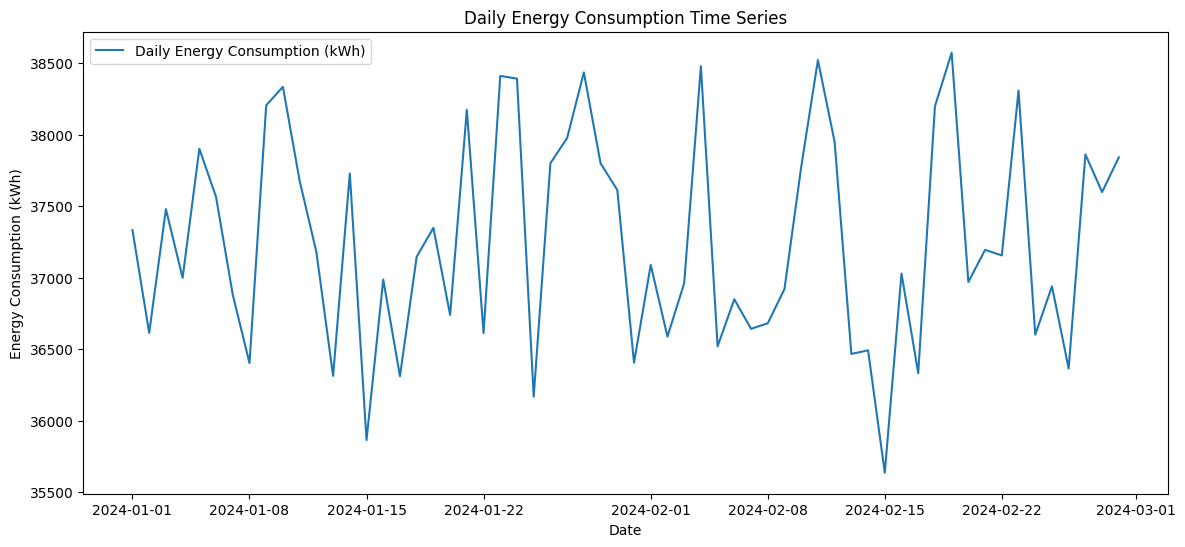

<Figure size 1200x600 with 0 Axes>

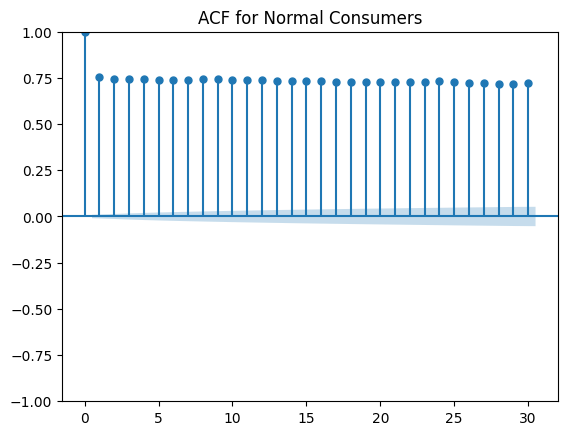

<Figure size 1200x600 with 0 Axes>

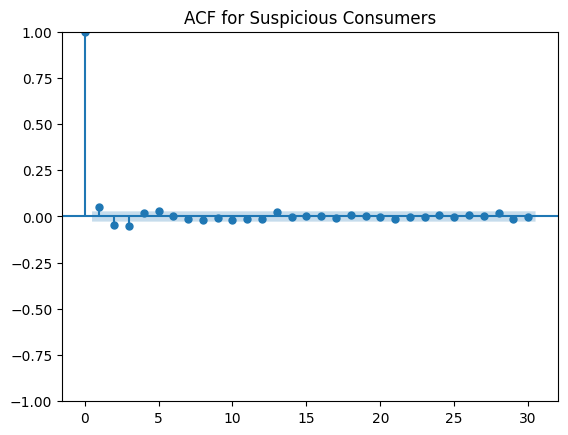

<Figure size 1200x600 with 0 Axes>

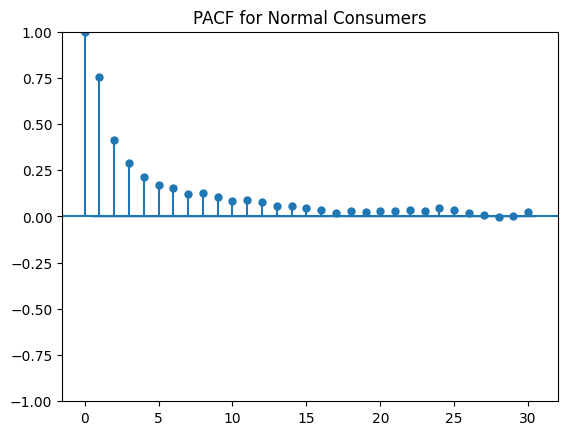

<Figure size 1200x600 with 0 Axes>

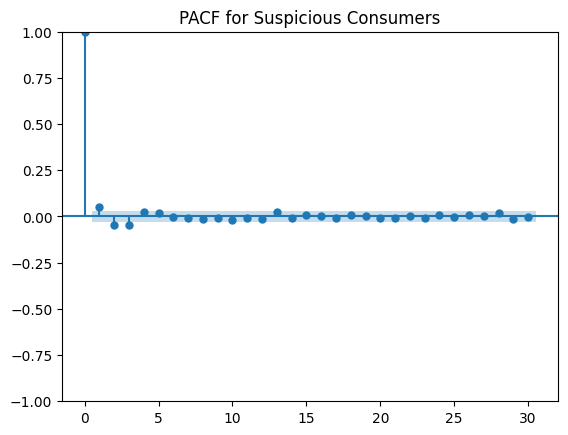

Normal Consumers Summary:
           Meter ID      Latitude     Longitude  Energy Consumption (kWh)  \
count  45000.000000  45000.000000  45000.000000              45000.000000   
mean      17.576378    -28.047969     26.766318                 30.123008   
std       10.220731      3.652859      3.780549                 34.918554   
min        1.000000    -33.960800     18.424100                  0.620000   
25%        8.000000    -29.858700     24.749100                  6.150000   
50%       17.000000    -26.204100     28.047300                 14.395000   
75%       27.000000    -25.474500     29.450000                 42.090000   
max       35.000000    -23.900000     31.021800                184.450000   

       Solar Generation (kWh)  Voltage (kV)  Frequency (Hz)  Power Factor  \
count            45000.000000  45000.000000    45000.000000  45000.000000   
mean                 3.494116    230.092684       50.001247      0.924622   
std                  4.904293      8.588605      

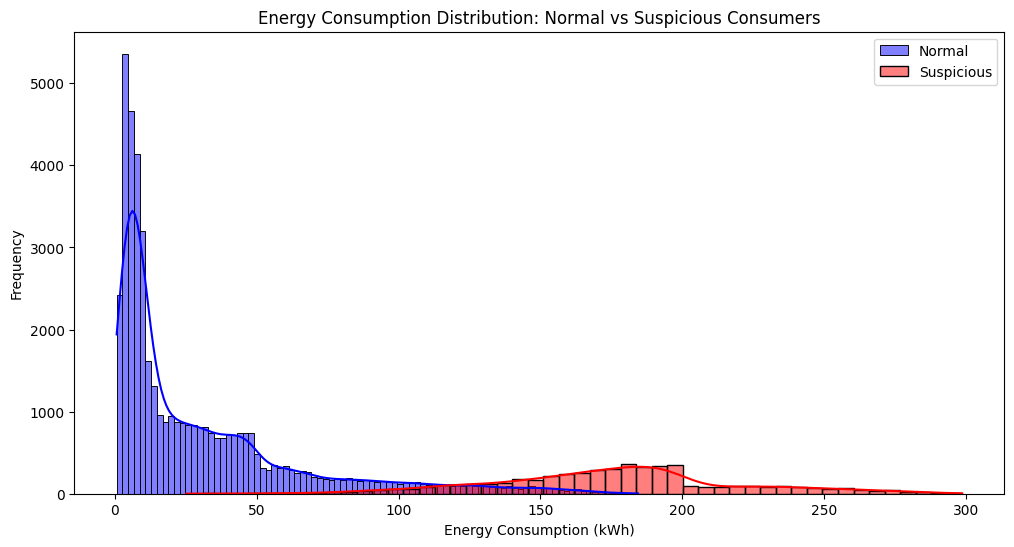

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      8994
           1       0.96      0.89      0.93      1006

    accuracy                           0.99     10000
   macro avg       0.97      0.95      0.96     10000
weighted avg       0.99      0.99      0.99     10000



In [7]:
# Run the Analysis
file_path = "data/smart_meter_grid_south_africa.csv"
df = load_and_preprocess(file_path)
X_scaled, features = prepare_features(df)
anomaly_labels = detect_anomalies(X_scaled)

# Visualize Results
visualize_results(df, X_scaled, anomaly_labels)
plot_time_series(df)
#plot_heatmaps(df)
plot_autocorrelation(df, anomaly_labels)
simulate_and_analyze(df, anomaly_labels)

# Build Prediction Model
prediction_model = build_prediction_model(df, anomaly_labels)

Starting city-level anomaly analysis...

Analyzing anomalies for Isolation Forest at the city level...
Top 5 cities with highest anomaly rates for Isolation Forest:
City
Bloemfontein     0.000000
Cape Town        0.034722
Durban          19.340278
Johannesburg    12.777778
Kimberley        7.691176
Name: Anomaly, dtype: float64


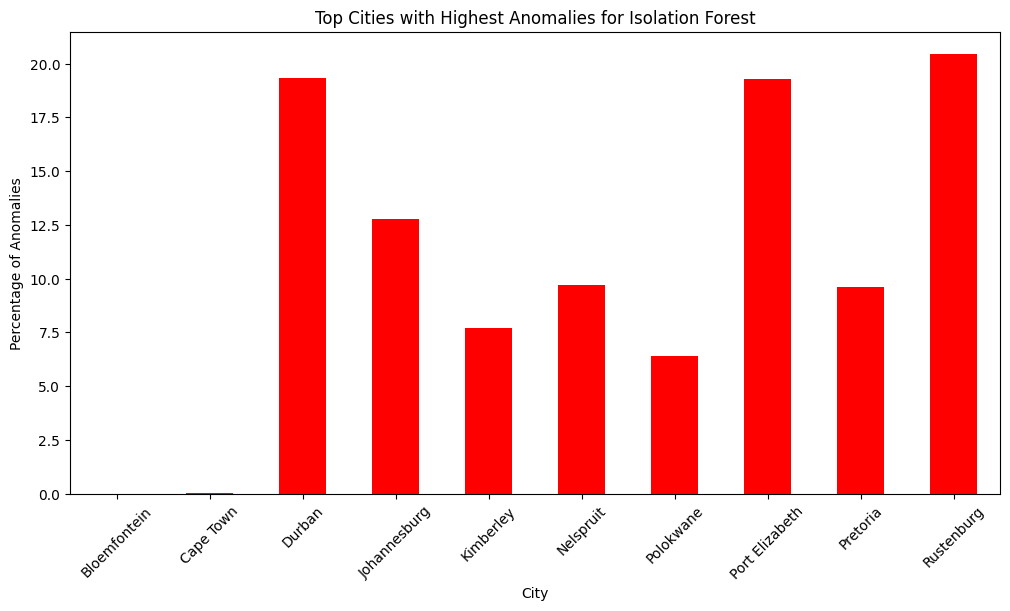


Analyzing anomalies for Local Outlier Factor at the city level...
Top 5 cities with highest anomaly rates for Local Outlier Factor:
City
Bloemfontein     3.750000
Cape Town        7.413194
Durban           7.708333
Johannesburg    10.092593
Kimberley       10.250000
Name: Anomaly, dtype: float64


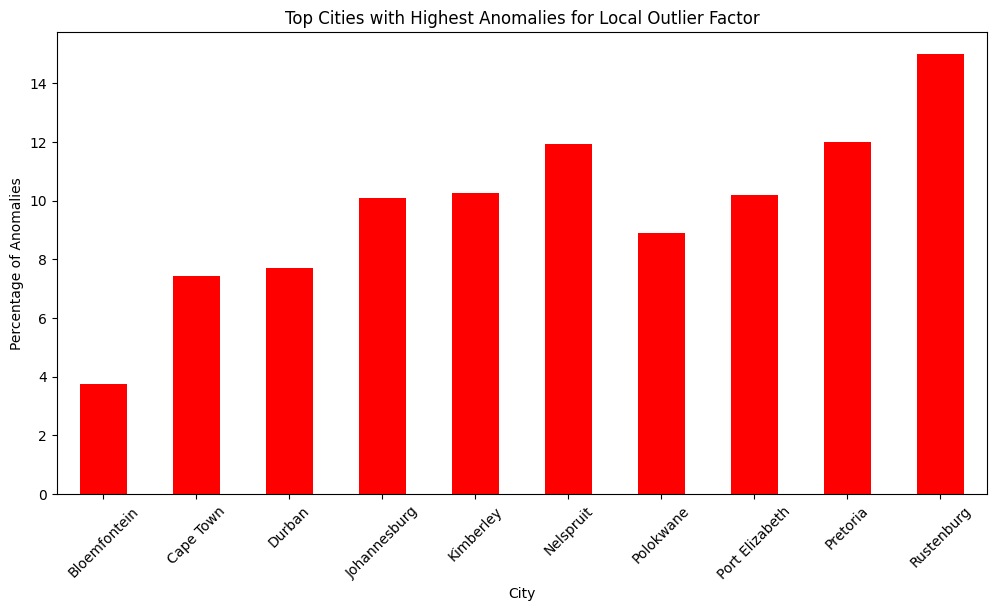


Analyzing anomalies for Robust Covariance at the city level...
Top 5 cities with highest anomaly rates for Robust Covariance:
City
Bloemfontein     0.000000
Cape Town        0.000000
Durban          19.131944
Johannesburg    12.291667
Kimberley        7.617647
Name: Anomaly, dtype: float64


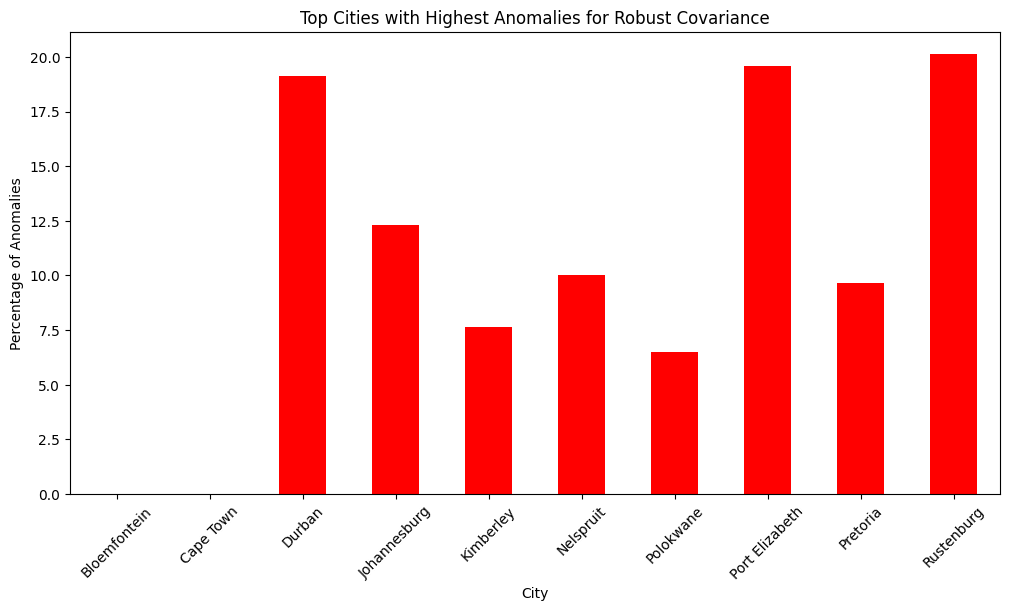


Analyzing anomalies for One-Class SVM at the city level...
Top 5 cities with highest anomaly rates for One-Class SVM:
City
Bloemfontein     7.083333
Cape Town        6.701389
Durban          15.173611
Johannesburg    10.856481
Kimberley        8.691176
Name: Anomaly, dtype: float64


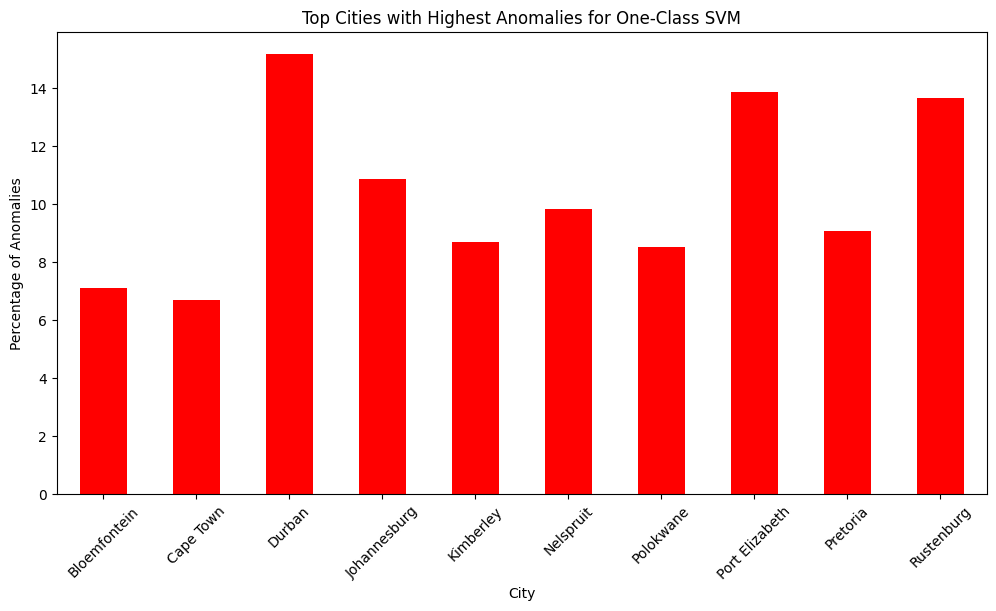


City-level anomaly analysis complete!


In [8]:
# Analyzing anomalies by city
def city_anomaly_analysis(df, anomaly_labels):
    city_anomaly_stats = {}

    for method, labels in anomaly_labels.items():
        print(f"\nAnalyzing anomalies for {method} at the city level...")
        
        # Add anomaly column to the dataframe
        df['Anomaly'] = (labels == -1).astype(int)
        
        # Group by city and calculate anomaly percentage
        city_anomaly = df.groupby('City')['Anomaly'].mean() * 100
        city_anomaly_stats[method] = city_anomaly.sort_values(ascending=False)
        
        # Print the cities with highest anomaly rates
        print(f"Top 5 cities with highest anomaly rates for {method}:")
        print(city_anomaly.head(5))
        
        # Visualize
        plt.figure(figsize=(12, 6))
        city_anomaly.head(10).plot(kind='bar', color='red')
        plt.title(f'Top Cities with Highest Anomalies for {method}')
        plt.xlabel('City')
        plt.ylabel('Percentage of Anomalies')
        plt.xticks(rotation=45)
        plt.show()
    
    return city_anomaly_stats

print("Starting city-level anomaly analysis...")
city_anomaly_stats = city_anomaly_analysis(df, anomaly_labels)
print("\nCity-level anomaly analysis complete!")


Starting daily consumption analysis...


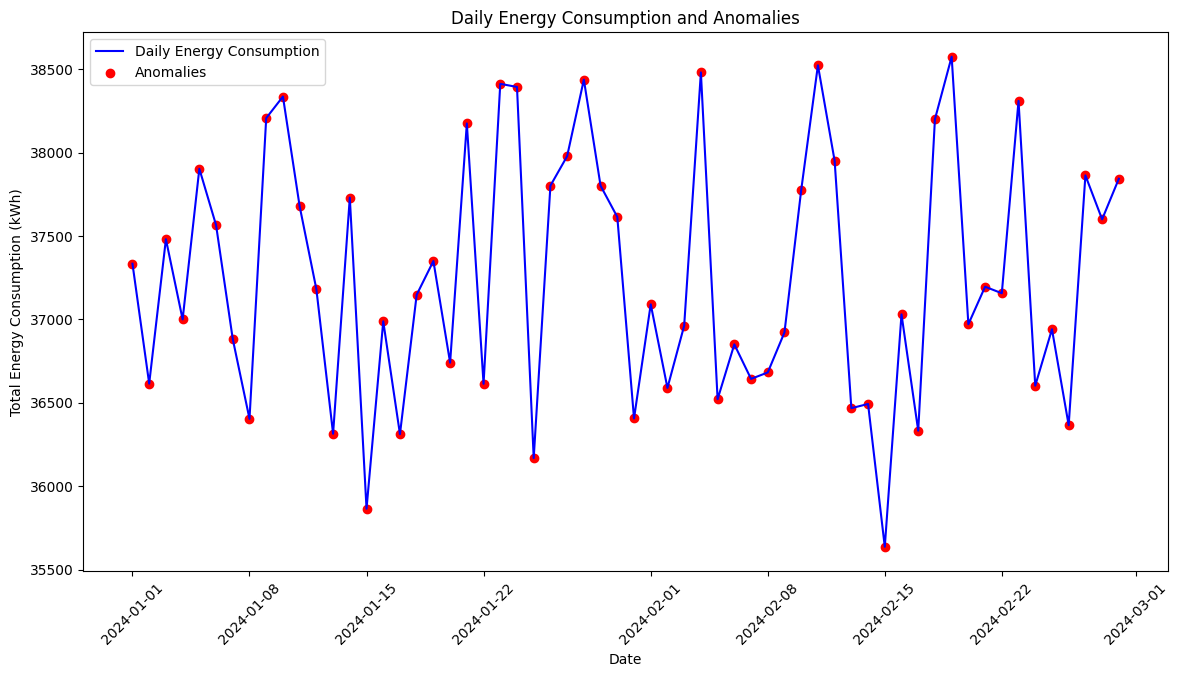


Daily consumption analysis complete!


In [9]:
# Time series analysis for daily consumption
def daily_consumption_analysis(df, anomaly_labels):
    df['Date'] = df['Timestamp'].dt.date
    df['Anomaly'] = (anomaly_labels['Isolation Forest'] == -1).astype(int)  # Using Isolation Forest for anomaly marking
    
    # Group by date and calculate daily total consumption
    daily_consumption = df.groupby('Date')['Energy Consumption (kWh)'].sum()
    daily_anomalies = df.groupby('Date')['Anomaly'].sum()
    
    # Plotting daily consumption with anomalies
    plt.figure(figsize=(14, 7))
    plt.plot(daily_consumption, label='Daily Energy Consumption', color='blue')
    plt.scatter(daily_consumption.index[daily_anomalies > 0], 
                daily_consumption[daily_anomalies > 0], 
                color='red', label='Anomalies')
    plt.title('Daily Energy Consumption and Anomalies')
    plt.xlabel('Date')
    plt.ylabel('Total Energy Consumption (kWh)')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

print("Starting daily consumption analysis...")
daily_consumption_analysis(df, anomaly_labels)
print("\nDaily consumption analysis complete!")


Starting fraud heatmap generation...


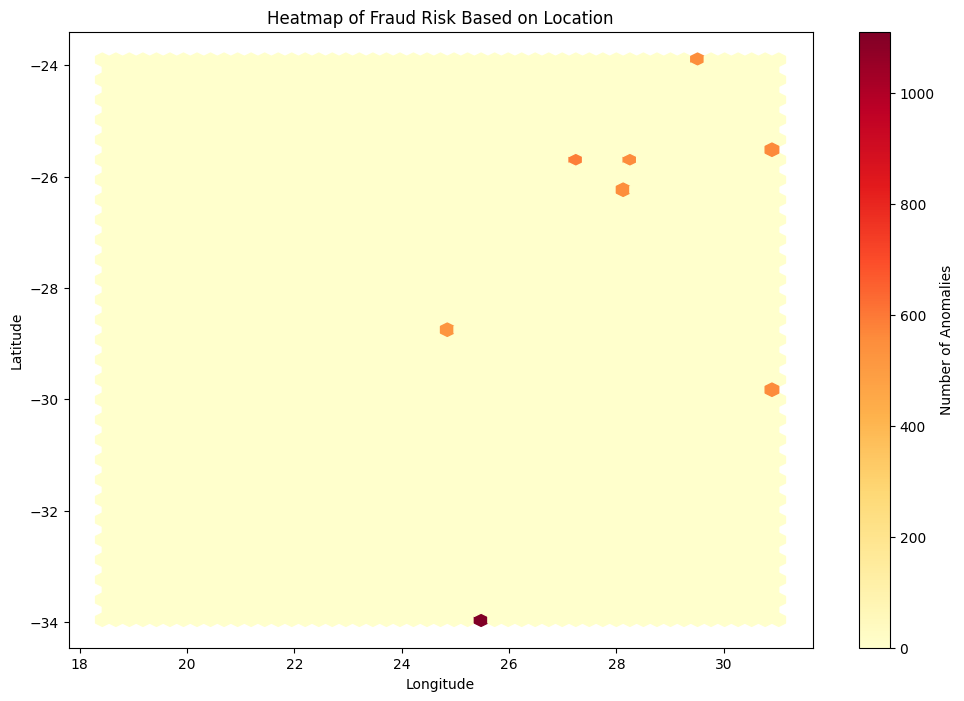


Fraud heatmap complete!


In [10]:
# Heatmap for fraud risk based on latitude and longitude
def fraud_heatmap(df, anomaly_labels):
    # Mark anomalies in the dataset
    df['Anomaly'] = (anomaly_labels['Isolation Forest'] == -1).astype(int)
    
    # Filter data for anomalies
    anomaly_data = df[df['Anomaly'] == 1]
    
    # Plotting the heatmap
    plt.figure(figsize=(12, 8))
    plt.hexbin(anomaly_data['Longitude'], anomaly_data['Latitude'], gridsize=50, cmap='YlOrRd')
    plt.colorbar(label='Number of Anomalies')
    plt.title('Heatmap of Fraud Risk Based on Location')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

print("Starting fraud heatmap generation...")
fraud_heatmap(df, anomaly_labels)
print("\nFraud heatmap complete!")


Starting fraud risk map generation with provinces...


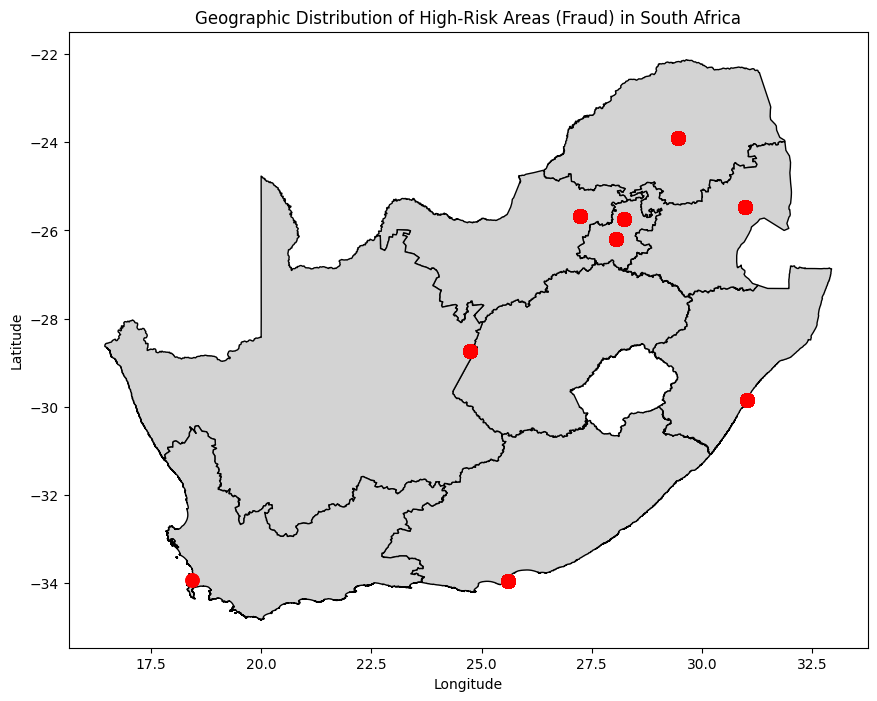


Fraud risk map with provinces complete!


In [11]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

def plot_map(df, anomaly_labels, shapefile_path):
    # Mark anomalies
    df['Anomaly'] = (anomaly_labels['Isolation Forest'] == -1).astype(int)
    
    # Filter anomalies
    anomaly_data = df[df['Anomaly'] == 1]
    
    # Load South African provinces shapefile
    sa_provinces = gpd.read_file(shapefile_path)
    
    # Convert the dataframe into GeoDataFrame
    geometry = [Point(xy) for xy in zip(anomaly_data['Longitude'], anomaly_data['Latitude'])]
    gdf = gpd.GeoDataFrame(anomaly_data, geometry=geometry)
    
    # Plot the South Africa map with provinces and fraud risk points
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot provinces
    sa_provinces.plot(ax=ax, color='lightgrey', edgecolor='black')
    
    # Plot fraud risk points (anomalies)
    gdf.plot(ax=ax, marker='o', color='red', markersize=90)
    
    # Title and labels
    plt.title('Geographic Distribution of High-Risk Areas (Fraud) in South Africa')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    
    # Show the plot
    plt.show()

# Define the path to the shapefile
shapefile_path = "zaf_adm_sadb_ocha_20201109_SHP/zaf_admbnda_adm1_sadb_ocha_20201109.shp"

# Generate the fraud risk map
print("Starting fraud risk map generation with provinces...")
plot_map(df, anomaly_labels, shapefile_path)
print("\nFraud risk map with provinces complete!")


In [12]:
# Predict fraud likelihood using the trained Random Forest model
def predict_high_risk_areas(df, model):
    print("Predicting high-risk fraud areas...")

    # Selecting features used during training
    features = [
        'Hour', 'Day', 'Month', 'DayOfWeek',
        'Energy Consumption (kWh)', 'Voltage (kV)',
        'Frequency (Hz)', 'Power Factor'
    ]
    
    # Predict fraud labels (1 = fraud, 0 = normal)
    df['Fraud_Prediction'] = model.predict(df[features])
    
    # Filter high-risk areas (fraud predicted)
    fraud_cases = df[df['Fraud_Prediction'] == 1]

    # Select important columns for reporting
    high_risk_list = fraud_cases[['Meter ID', 'Province', 'City', 'Latitude', 'Longitude']]
    
    print("\n### Predicted High-Risk Areas ###")
    print(high_risk_list.to_string(index=False))  # Print list without index

    return high_risk_list

# Run the fraud prediction and print results
high_risk_list = predict_high_risk_areas(df, prediction_model)

Predicting high-risk fraud areas...

### Predicted High-Risk Areas ###
 Meter ID      Province           City  Latitude  Longitude
        2 Northern Cape      Kimberley  -28.7282    24.7491
        2 Northern Cape      Kimberley  -28.7282    24.7491
        5       Gauteng   Johannesburg  -26.2041    28.0473
        5       Gauteng   Johannesburg  -26.2041    28.0473
        7       Limpopo      Polokwane  -23.9000    29.4500
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     Rustenburg  -25.6676    27.2421
        9    North West     R

In [13]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Assume df is already preprocessed and loaded
features = ['Hour', 'Day', 'Month', 'DayOfWeek', 'Energy Consumption (kWh)', 'Voltage (kV)', 'Frequency (Hz)', 'Power Factor']
X = df[features]
y = (df['Fraud'] == 1).astype(int)  # Convert fraud column to 0/1

# Train a simple RandomForest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Save the model
joblib.dump(model, "fraud_detection_model.pkl")
print("Model saved as fraud_detection_model.pkl")


Model saved as fraud_detection_model.pkl


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import joblib

# Load the dataset
df = pd.read_csv("data/smart_meter_grid_south_africa.csv")

# Convert Timestamp to DateTime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract time-based features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# Define model input features
features = [
    'Hour', 'Day', 'Month', 'DayOfWeek',
    'Energy Consumption (kWh)', 'Voltage (kV)',
    'Frequency (Hz)', 'Power Factor'
]

# Load trained model
model = joblib.load("fraud_detection_model.pkl")

# Separate features & target (Assuming 'Fraud' column exists in dataset)
X = df[features]
y_true = df['Fraud']  # Actual fraud labels (1 = Fraud, 0 = Normal)

# Make fraud predictions
y_pred = model.predict(X)

# Print classification report
print("\n🔍 **Model Performance Metrics:**")
print(classification_report(y_true, y_pred))

# Confusion Matrix
print("\n📊 **Confusion Matrix:**")
conf_matrix = confusion_matrix(y_true, y_pred)
print(conf_matrix)



🔍 **Model Performance Metrics:**
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     47434
           1       1.00      1.00      1.00      2566

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000


📊 **Confusion Matrix:**
[[47434     0]
 [    2  2564]]


 Model Evaluation Metrics:
Accuracy:  0.9508
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000
ROC-AUC:   0.5000


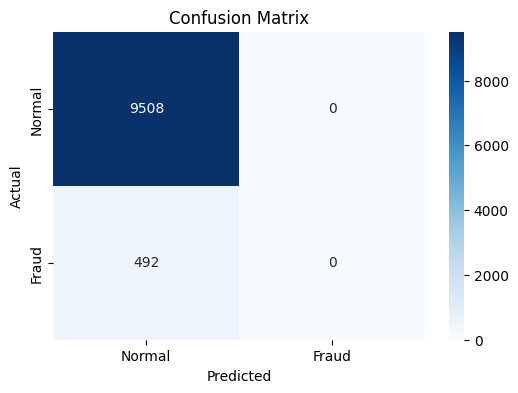

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Function to evaluate the model
def evaluate_model(model, X_test, y_test):
    # Predict on test data
    y_pred = model.predict(X_test)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    # Display metrics
    print(f" Model Evaluation Metrics:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# Split Data (Ensure you have train-test split)
from sklearn.model_selection import train_test_split

X = df[features]
y = (df['Fraud'] == 1).astype(int)  # Convert fraud column to binary

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate Model
evaluate_model(model, X_test, y_test)


To compare different fraud detection algorithms and visualize their performance trends, we will:

**Train multiple models:**

Random Forest
Isolation Forest
Logistic Regression
XGBoost

**Evaluate each model using:**

Accuracy, Precision, Recall, F1-Score, ROC-AUC

 Training Random Forest...
 Training Logistic Regression...
 Training XGBoost...


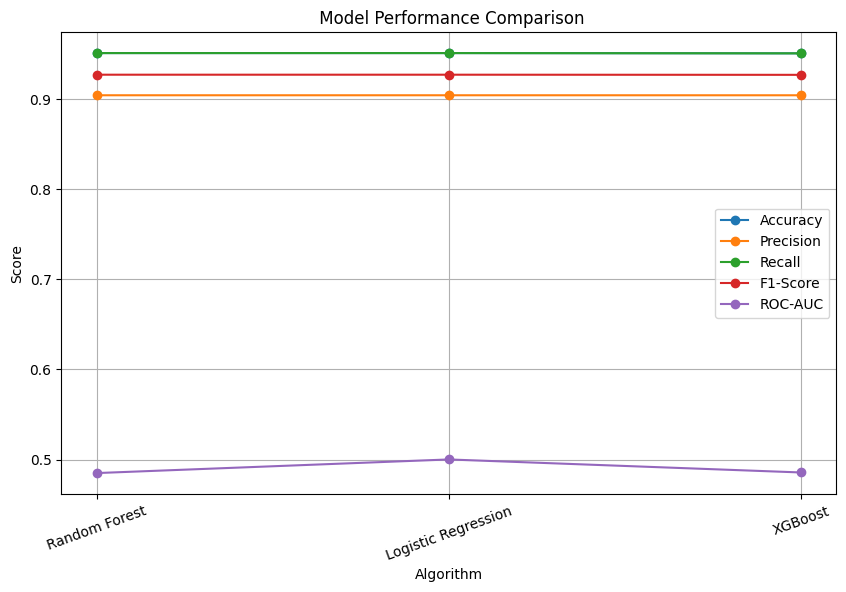


 Model Performance Summary:
                 Model  Accuracy  Precision  Recall  F1-Score   ROC-AUC
0        Random Forest    0.9508   0.904021  0.9508   0.92682  0.485074
1  Logistic Regression    0.9508   0.904021  0.9508   0.92682  0.500185
2              XGBoost    0.9505   0.904007  0.9505   0.92667  0.485743


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Load dataset
df = pd.read_csv("data/smart_meter_grid_south_africa.csv")

# Ensure 'Timestamp' is formatted correctly
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Handle missing values (to prevent errors)
df.dropna(inplace=True)

# Extract time-based features
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

# Ensure 'Fraud' column exists
if 'Fraud' not in df.columns:
    raise ValueError(" Column 'Fraud' not found in dataset!")

# Define features & target variable
features = ['Hour', 'Day', 'Month', 'DayOfWeek', 'Energy Consumption (kWh)', 'Voltage (kV)', 'Frequency (Hz)', 'Power Factor']
X = df[features]
y = df['Fraud'].astype(int)  # Convert fraud column to binary (1 = Fraud, 0 = Normal)

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    
}

# Store evaluation metrics
performance = []

# Train & evaluate each model
for name, model in models.items():
    print(f" Training {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    # Store results
    performance.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Convert to DataFrame
performance_df = pd.DataFrame(performance)

#  Plot Trend Line Graph for Model Performance
plt.figure(figsize=(10, 6))

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    plt.plot(performance_df["Model"], performance_df[metric], marker='o', label=metric)

plt.title(" Model Performance Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.legend()
plt.xticks(rotation=20)
plt.grid()
plt.show()

# Display table of results
print("\n Model Performance Summary:")
print(performance_df)
